# Exercise 1
**Cristina Correa - 1819211867**


Use Keras to create a simple feedforward network to classify or predict
on tabular data, like the UCI heart disease dataset.
The dataset is available via the sklearn library and more information can be found
here:
https://archive.ics.uci.edu/dataset/45/heart+disease
- The dataset has several features and one target column that represent diagnosis of
heart disease.
- Initially we will start with importing the necessary libraries as follows

In [17]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras import layers, Model
from keras.callbacks import EarlyStopping

# Ensure TensorFlow backend
os.environ["KERAS_BACKEND"] = "tensorflow"

In [18]:
file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

In [19]:
dataframe.shape

(303, 14)

In [20]:
"""
Here's a preview of a few samples:
"""

dataframe.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [21]:
"""
Let's split the data into a training and validation set:
"""

val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)
print(
    f"Using {len(train_dataframe)} samples for training "
    f"and {len(val_dataframe)} for validation"
)

Using 242 samples for training and 61 for validation


In [22]:
# Convert dataframes to tf.data.Datasets
def dataframe_to_dataset(dataframe, target="target"):
  dataframe = dataframe.copy()
  labels = dataframe.pop(target)
  ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
  ds = ds.shuffle(buffer_size=len(dataframe)).batch(32)
  return ds

In [23]:
"""
Let's generate `tf.data.Dataset` objects for each dataframe:
"""

train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)

In [24]:
# Preprocessing layers for numerical and categorical features
def encode_feature(feature, name, dataset, is_string=False):
  lookup_class = layers.StringLookup if is_string else layers.IntegerLookup
  lookup = lookup_class(output_mode="binary")
  feature_ds = dataset.map(lambda x, y: x[name]).map(lambda x:
  tf.expand_dims(x, -1))
  lookup.adapt(feature_ds)
  return lookup(feature)

def normalize_feature(feature, name, dataset):
  normalizer = layers.Normalization()
  feature_ds = dataset.map(lambda x, y: tf.expand_dims(x[name], -1))
  normalizer.adapt(feature_ds)
  return normalizer(feature)


In [25]:
inputs = {
    "age": layers.Input(name="age", shape=(1,), dtype="float32"),
    "sex": layers.Input(name="sex", shape=(1,), dtype="int64"),
    "cp": layers.Input(name="cp", shape=(1,), dtype="int64"),
    "trestbps": layers.Input(name="trestbps", shape=(1,), dtype="float32"),
    "chol": layers.Input(name="chol", shape=(1,), dtype="float32"),
    "fbs": layers.Input(name="fbs", shape=(1,), dtype="int64"),
    "restecg": layers.Input(name="restecg", shape=(1,), dtype="int64"),
    "thalach": layers.Input(name="thalach", shape=(1,), dtype="float32"),
    "exang": layers.Input(name="exang", shape=(1,), dtype="int64"),
    "oldpeak": layers.Input(name="oldpeak", shape=(1,), dtype="float32"),
    "slope": layers.Input(name="slope", shape=(1,), dtype="int64"),
    "ca": layers.Input(name="ca", shape=(1,), dtype="int64"),
    "thal": layers.Input(name="thal", shape=(1,), dtype="string"),
}

# Encoded features
encoded_features = [
    encode_feature(inputs["sex"], "sex", train_ds),
    encode_feature(inputs["cp"], "cp", train_ds),
    encode_feature(inputs["fbs"], "fbs", train_ds),
    encode_feature(inputs["restecg"], "restecg", train_ds),
    encode_feature(inputs["exang"], "exang", train_ds),
    encode_feature(inputs["ca"], "ca", train_ds),
    encode_feature(inputs["thal"], "thal", train_ds, is_string=True),
    normalize_feature(inputs["age"], "age", train_ds),
    normalize_feature(inputs["trestbps"], "trestbps", train_ds),
    normalize_feature(inputs["chol"], "chol", train_ds),
    normalize_feature(inputs["thalach"], "thalach", train_ds),
    normalize_feature(inputs["oldpeak"], "oldpeak", train_ds),
    normalize_feature(inputs["slope"], "slope", train_ds),
]

In [26]:
# Build the model
def build_model():
  # Concatenate all features and define the model layers
  all_features = layers.concatenate(encoded_features)
  x = layers.Dense(32, activation='relu')(all_features)
  # x = layers.Dense(16,activation='relu')(x)
  output = layers.Dense(1, activation='sigmoid')(x)
  
  # Compile the model
  model = Model(inputs, output)
  model.compile(optimizer='adam', loss='binary_crossentropy',
  metrics=['accuracy'])
  return model

In [27]:
model = build_model()

In [28]:
history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.2537 - loss: 0.8787 - val_accuracy: 0.2131 - val_loss: 0.8379
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2825 - loss: 0.7901 - val_accuracy: 0.3934 - val_loss: 0.7481
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4645 - loss: 0.6983 - val_accuracy: 0.5738 - val_loss: 0.6757
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6404 - loss: 0.6436 - val_accuracy: 0.6557 - val_loss: 0.6166
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6931 - loss: 0.6029 - val_accuracy: 0.7213 - val_loss: 0.5692
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7082 - loss: 0.5549 - val_accuracy: 0.7869 - val_loss: 0.5299
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7379 - loss: 0.5243 - val_accuracy: 0.7869 - val_loss: 0.4989
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8103 - loss: 0.4655 - val_accuracy: 0.8033 - val_loss: 0.4732
Epoch 9

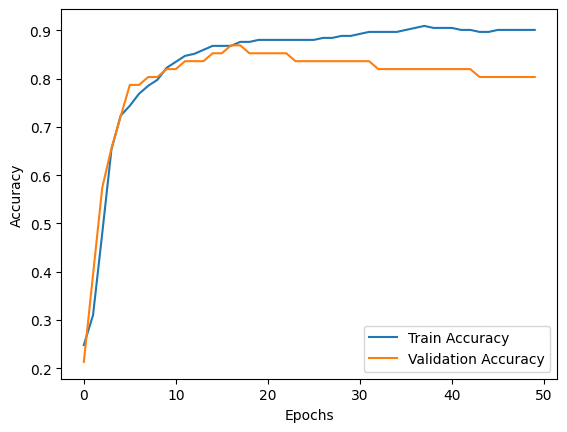

In [29]:
# Plot training history
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [32]:
# Inference on a new sample
sample = {
"age": 60, "sex": 1, "cp": 1, "trestbps": 145, "chol": 233,
"fbs": 1, "restecg": 2, "thalach": 150, "exang": 0,
"oldpeak": 2.3, "slope": 3, "ca": 0, "thal": "fixed",
}

input_dict = {name: tf.convert_to_tensor([value]) for name, value in
sample.items()}
predictions = model.predict(input_dict)

print(f"This patient has a {100 * predictions[0][0]:.1f}% probability of heart disease.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
This patient has a 15.1% probability of heart disease.
